## Credit Risk Assesment

In [3]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from ydata_profiling import ProfileReport
from swiftmltoolz import plot_corr_heatmap,print_mutual_information
from xgboost import XGBClassifier
%matplotlib inline

In [4]:
# loading dataset
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### EDA

In [5]:
df_credit = df.copy()
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df_credit.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df_credit.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
#dropping duplicates
print(df_credit.duplicated().sum())
df_credit.drop_duplicates(inplace=True)
df.drop_duplicates(inplace=True)


165


In [9]:
df_credit.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [10]:
#na columns
na_columns = ['loan_int_rate','person_emp_length']

Text(0.5, 1.0, 'Countplot of target variable ----> loan_status')

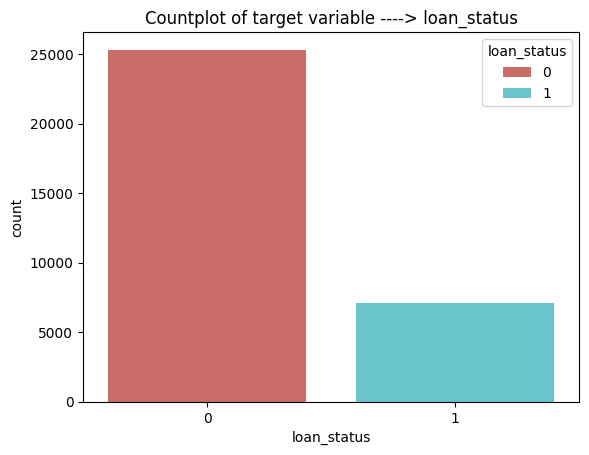

In [11]:
#checking the count of target variable
sns.countplot(df_credit,x='loan_status',hue="loan_status",palette="hls")
plt.title("Countplot of target variable ----> loan_status")
# imbalanced target variable will need to be addressed

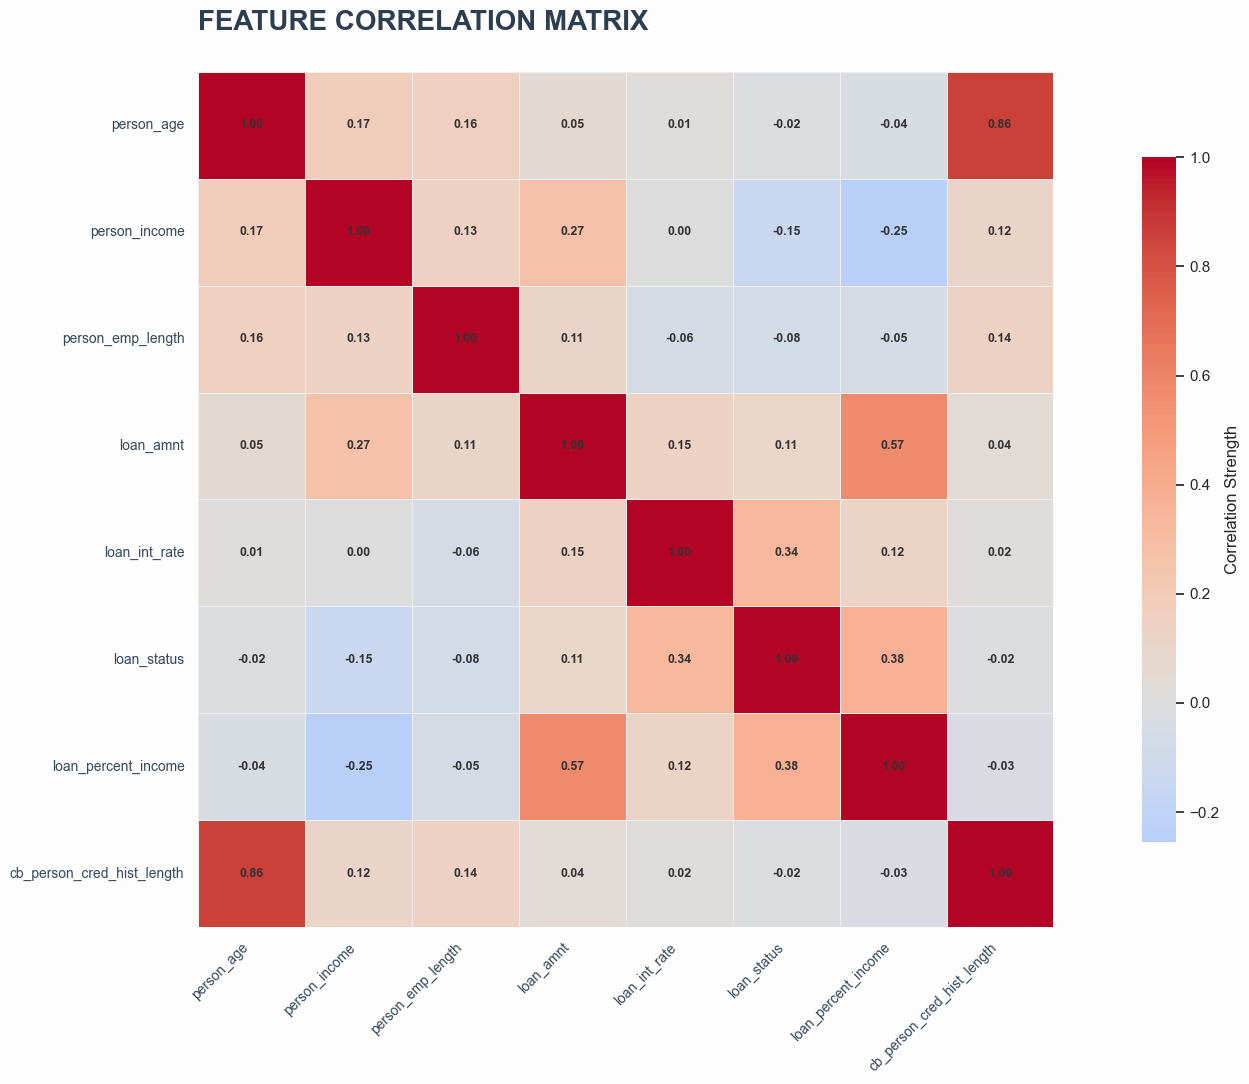

In [12]:
# numerical analysis
plot_corr_heatmap(df_credit,cmap="coolwarm")

##### There appears to be a high correlation between person_age and cb_person_cred_hist_length and loan status appear to be correlated mildly with loan_percent_income,loan_interest_rate and loan_amount

In [13]:
# splitting columns into numerical and categorical
num_cols = df_credit.dtypes[df_credit.dtypes != 'object'].index
cat_cols = df_credit.dtypes[df_credit.dtypes == 'object'].index

In [14]:
df_credit[num_cols]

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,1,0.59,3
1,21,9600,5.0,1000,11.14,0,0.10,2
2,25,9600,1.0,5500,12.87,1,0.57,3
3,23,65500,4.0,35000,15.23,1,0.53,2
4,24,54400,8.0,35000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30
32577,54,120000,4.0,17625,7.49,0,0.15,19
32578,65,76000,3.0,35000,10.99,1,0.46,28
32579,56,150000,5.0,15000,11.48,0,0.10,26


In [15]:
df_credit[cat_cols]

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
...,...,...,...,...
32576,MORTGAGE,PERSONAL,C,N
32577,MORTGAGE,PERSONAL,A,N
32578,RENT,HOMEIMPROVEMENT,B,N
32579,MORTGAGE,PERSONAL,B,N


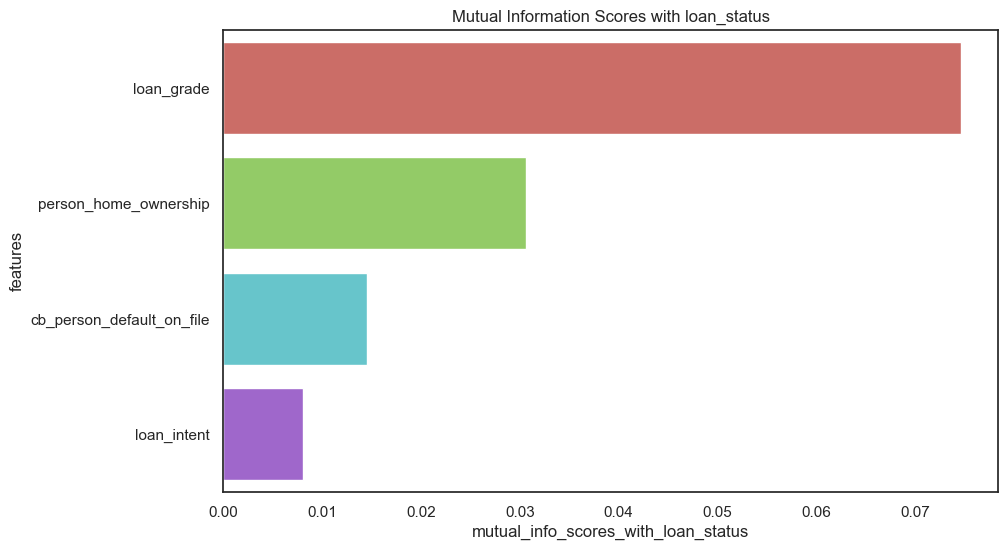

,mutual_info_scores_with_loan_status
features,
loan_grade,0.074664
person_home_ownership,0.030615
cb_person_default_on_file,0.014552
loan_intent,0.008110


In [16]:
print_mutual_information(df_credit,cat_cols,y="loan_status",plot_bar=True)

In [17]:
df_credit.loan_int_rate.mean()

np.float64(11.017265100098905)

In [18]:
global_loan_default_rate = round(df_credit.loan_status.mean() * 100,2)
global_loan_default_rate

np.float64(21.87)

##### EDA with loan_interest_rate

In [19]:
print("minimium value of loan interest rate ---->", df_credit.loan_int_rate.min())
print("median value of loan interest rate ---->", df_credit.loan_int_rate.median())
print("mean value of loan interest rate ---->", df_credit.loan_int_rate.mean())
print("max value of loan interest rate ---->", df_credit.loan_int_rate.max())

minimium value of loan interest rate ----> 5.42
median value of loan interest rate ----> 10.99
mean value of loan interest rate ----> 11.017265100098905
max value of loan interest rate ----> 23.22


In [20]:
print("loan default rate for clients with below mean average rate ---->", df_credit[df_credit.loan_int_rate < 11].loan_status.mean() * 100)
print("loan default rate for clients with above mean average rate ---->", df_credit[df_credit.loan_int_rate > 11].loan_status.mean() * 100)

loan default rate for clients with below mean average rate ----> 12.128161888701518
loan default rate for clients with above mean average rate ----> 32.07781456953642


##### The loan default rate for clients with interest rates higher than the average are more likely to default than those with lower interest rate

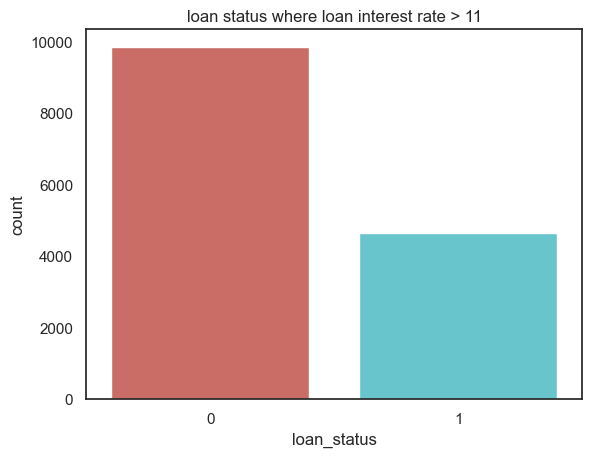

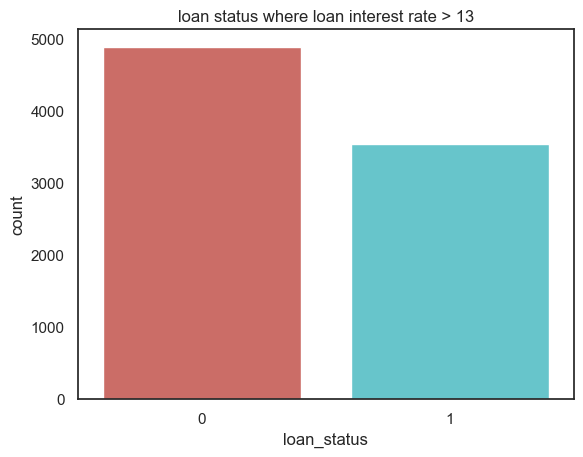

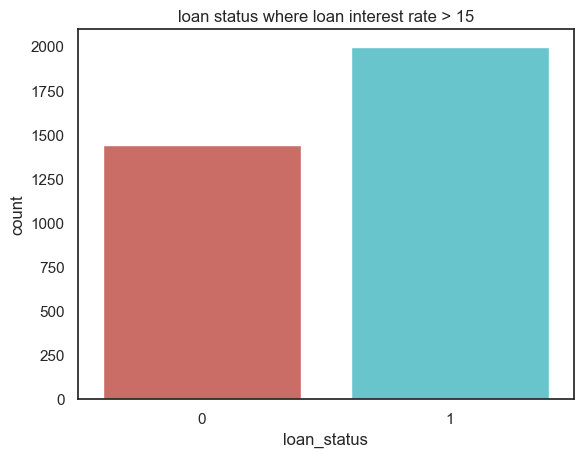

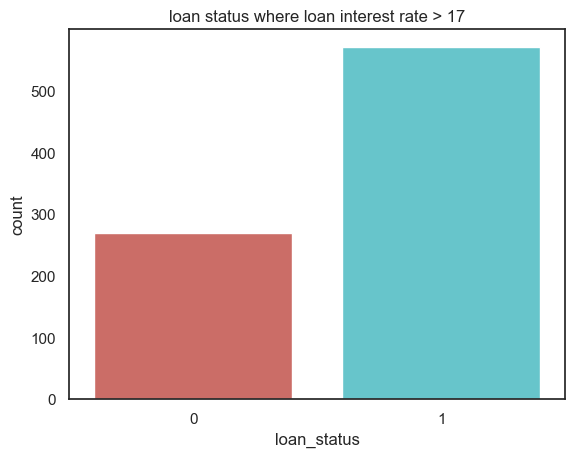

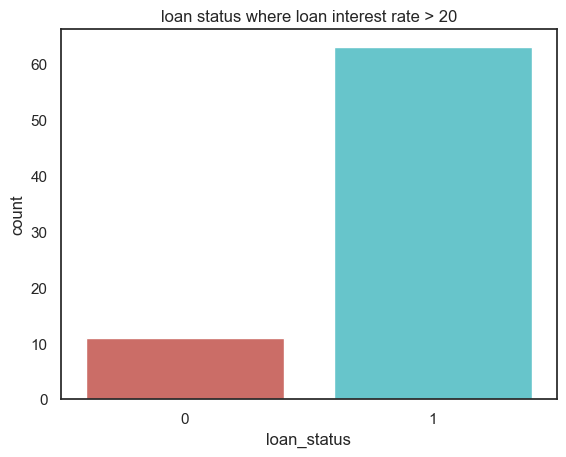

In [21]:
for num in [11,13,15,17,20]:
    sns.countplot(data=df_credit[df_credit.loan_int_rate > num], x="loan_status",hue="loan_status",palette="hls", legend=False)
    plt.title(f"loan status where loan interest rate > {num}")
    plt.show()
    
    

##### loan amount

minimium value of loan_amount ----> 500
median value of loan_amount ----> 8000.0
mean value of loan_amount ----> 9593.845631786771
max value of loan_amount ----> 35000
loan default rate for clients with below mean average loan amount ----> 19.031957463136546
loan default rate for clients with above mean average loan amount ----> 25.545370567753857


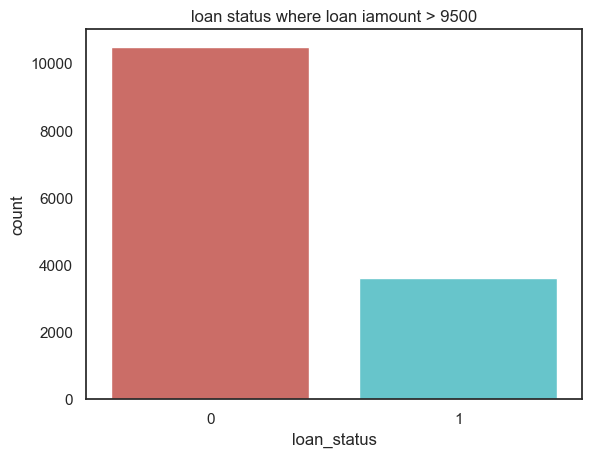

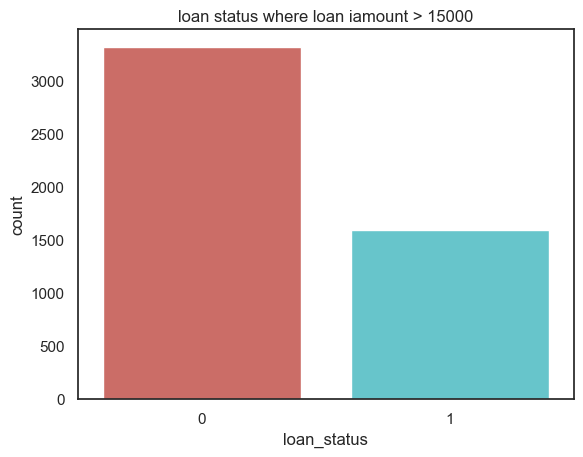

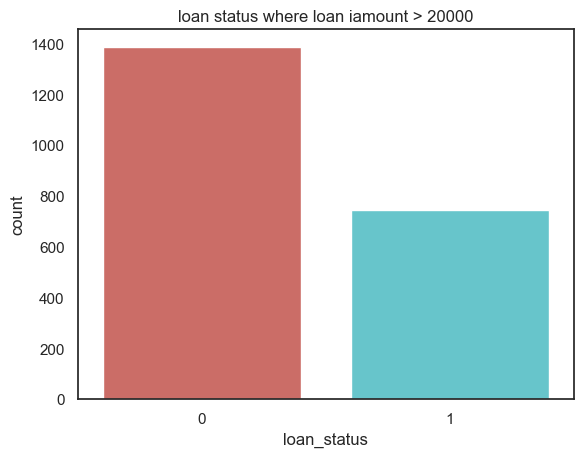

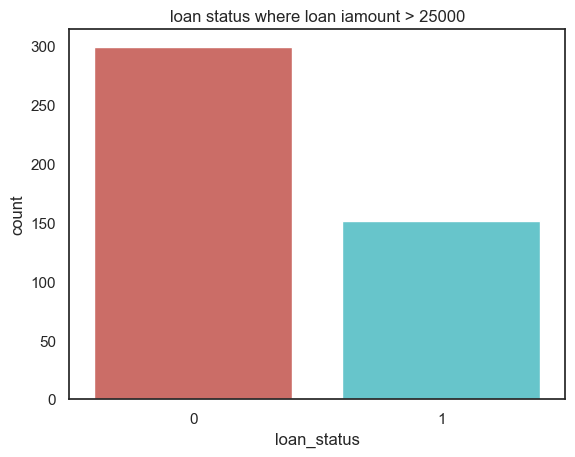

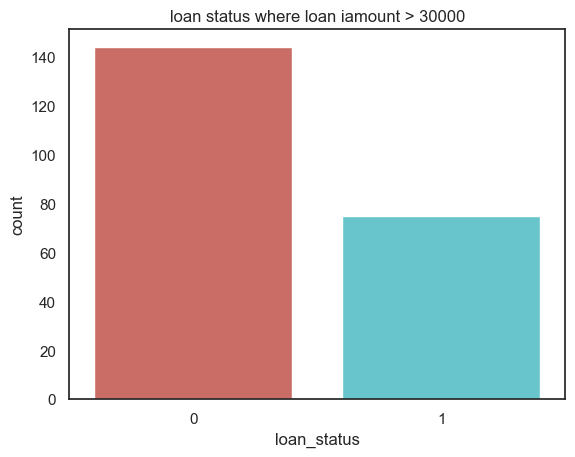

In [22]:
print("minimium value of loan_amount ---->", df_credit.loan_amnt.min())
print("median value of loan_amount ---->", df_credit.loan_amnt.median())
print("mean value of loan_amount ---->", df_credit.loan_amnt.mean())
print("max value of loan_amount ---->", df_credit.loan_amnt.max())
print("loan default rate for clients with below mean average loan amount ---->", df_credit[df_credit.loan_amnt < 9500].loan_status.mean() * 100)
print("loan default rate for clients with above mean average loan amount ---->", df_credit[df_credit.loan_amnt > 9500].loan_status.mean() * 100)
# plot
for num in [9500,15000,20000,25000,30000]:
    sns.countplot(data=df_credit[df_credit.loan_amnt > num], x="loan_status",hue="loan_status",palette="hls", legend=False)
    plt.title(f"loan status where loan iamount > {num}")
    plt.show()

45.57640750670242


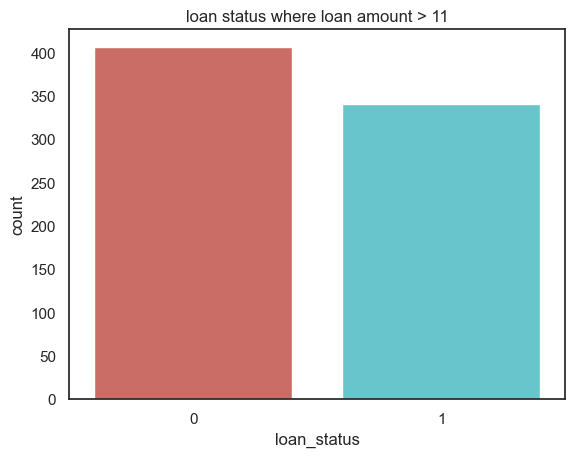

55.27831094049904


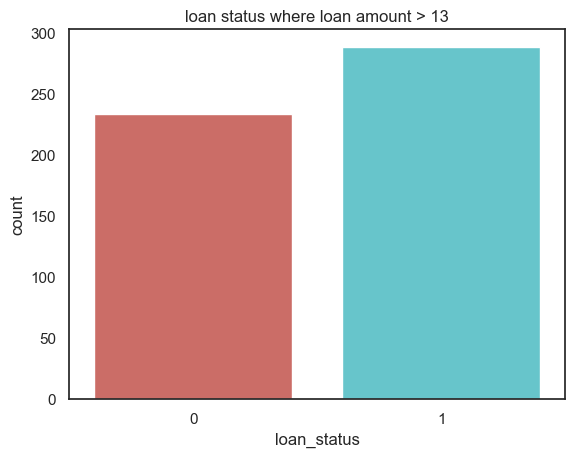

58.93854748603352


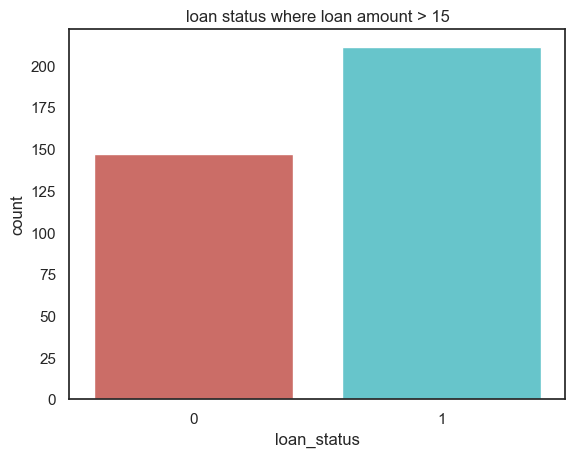

70.76923076923077


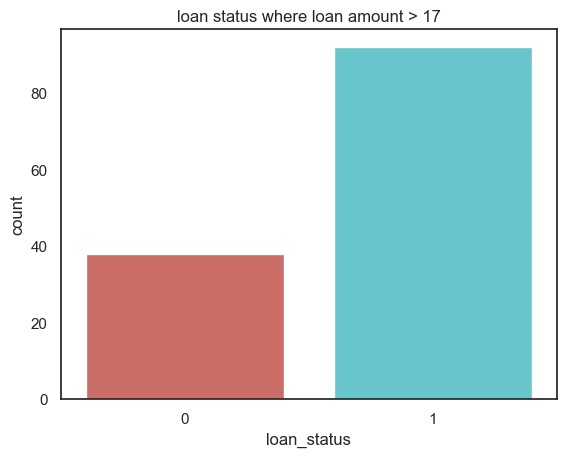

93.33333333333333


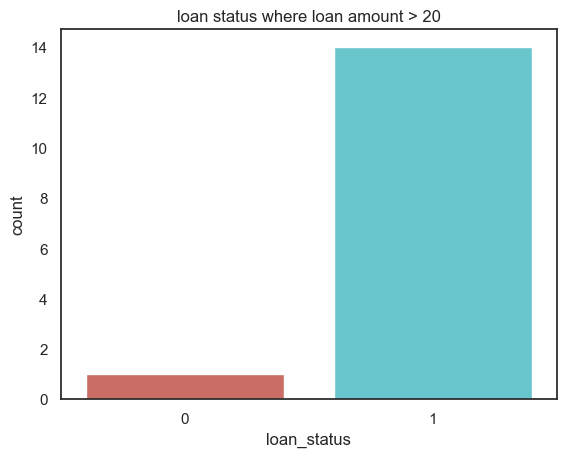

In [23]:
for num in [11,13,15,17,20]:
    print(df_credit[(df_credit.loan_int_rate > num) & (df_credit.loan_amnt >= 25000)].loan_status.mean() * 100)
    sns.countplot(data=df_credit[(df_credit.loan_int_rate > num) & (df_credit.loan_amnt >= 25000)], x="loan_status",hue="loan_status",palette="hls", legend=False)
    plt.title(f"loan status where loan amount > {num}")
    plt.show()
    

##### clients with a combination of  high loan amount of 25000 and an above average loan interest are likely to default with clients with an interest rate of 20 and loan amount >  25000  having a fefault rate of about 93%

##### loan percent income

minimium value of loan_percent_income ----> 0.0
median value of loan_percent_income ----> 0.15
mean value of loan_percent_income ----> 0.1702498766041461
max value of loan_percent_income ----> 0.83
loan default rate for clients with below mean average loan percent income ----> 12.477306486218847
loan default rate for clients with above mean average loan percent income ----> 35.456295725837506


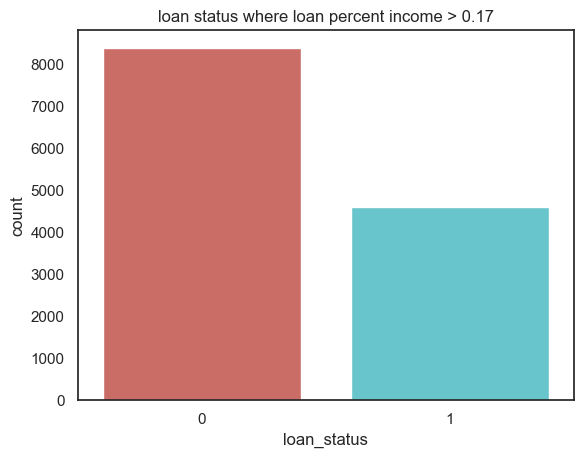

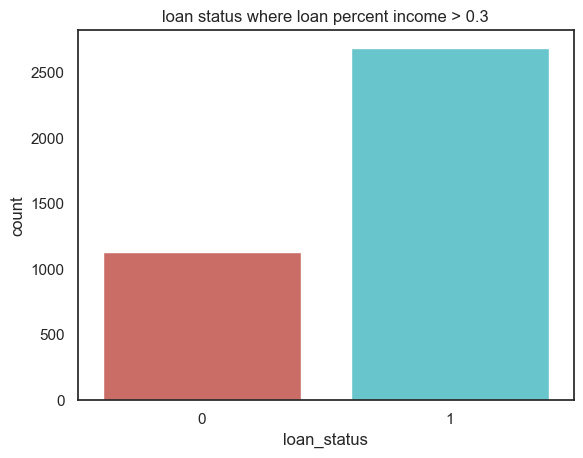

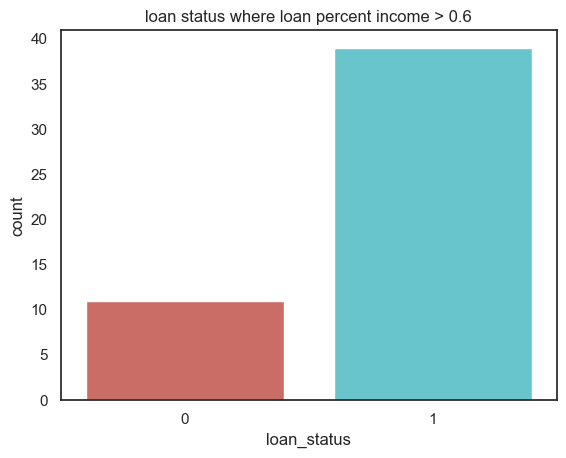

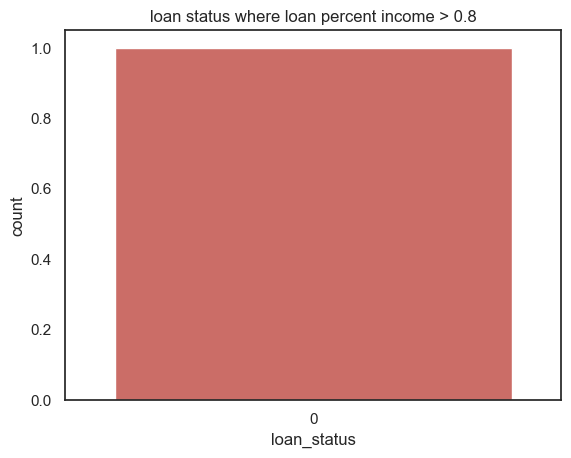

In [24]:
print("minimium value of loan_percent_income ---->", df_credit.loan_percent_income.min())
print("median value of loan_percent_income ---->", df_credit.loan_percent_income.median())
print("mean value of loan_percent_income ---->", df_credit.loan_percent_income.mean())
print("max value of loan_percent_income ---->", df_credit.loan_percent_income.max())
print("loan default rate for clients with below mean average loan percent income ---->", df_credit[df_credit.loan_percent_income < 0.17].loan_status.mean() * 100)
print("loan default rate for clients with above mean average loan percent income ---->", df_credit[df_credit.loan_percent_income > 0.17].loan_status.mean() * 100)
# plot
for num in [0.17,0.30,0.60,0.80]:
    sns.countplot(data=df_credit[df_credit.loan_percent_income > num], x="loan_status",hue="loan_status",palette="hls", legend=False)
    plt.title(f"loan status where loan percent income > {num}")
    plt.show()

In [25]:
print(df_credit[df_credit.loan_percent_income > 0.78].loan_status.mean()) #checking default rate
# visiualizing the instance
df_credit[df_credit.loan_percent_income > 0.78]

0.0


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
640,22,20000,MORTGAGE,0.0,PERSONAL,B,16600,9.76,0,0.83,N,3


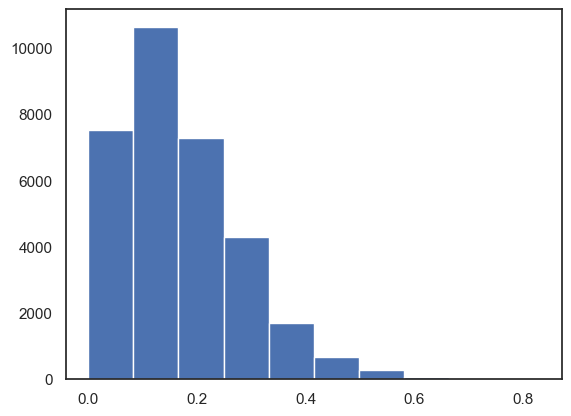

In [26]:
#visualizing percent income
plt.hist(x=df_credit.loan_percent_income)
plt.show()

#### We notice an increase in defulters as the loan percent income increases from above the mean to 0.80% (0.78 precisely) where we notice an abrupt absence of defaulters. The data currently do not have enough instances with percent income above 0.83. The thinning of he sample size via the histogram confirms this. 

##### loan grade


In [27]:
df_credit.loan_grade.unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [28]:
for letter in ['A','B','C','D','E', 'F', 'G']: 
    print (f"default rate for instances with loan grade = {letter}  -----> {df_credit[df_credit.loan_grade == letter].loan_status.mean() * 100}")

default rate for instances with loan grade = A  -----> 9.959824348313557
default rate for instances with loan grade = B  -----> 16.318475016847984
default rate for instances with loan grade = C  -----> 20.751786269027647
default rate for instances with loan grade = D  -----> 59.06077348066299
default rate for instances with loan grade = E  -----> 64.48598130841121
default rate for instances with loan grade = F  -----> 70.53941908713693
default rate for instances with loan grade = G  -----> 98.4375


##### The default rate of clients with loan grade of D,E,F,G are all likely to be defaulters since their local default rate is way above the global default rate.

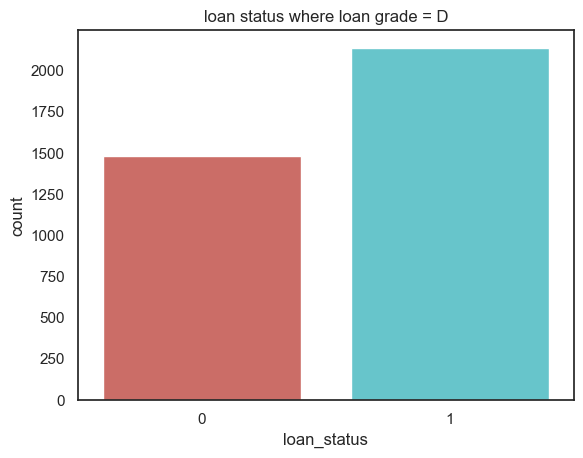

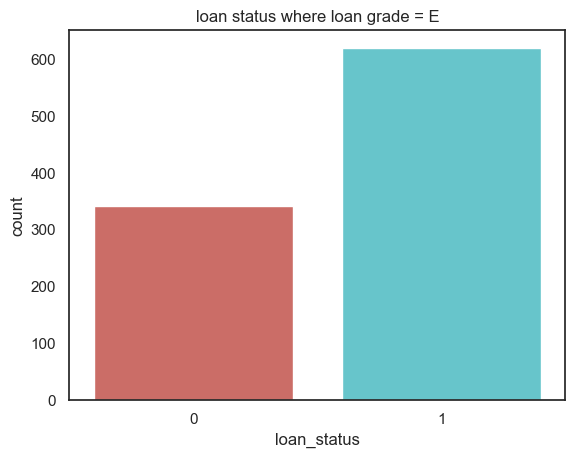

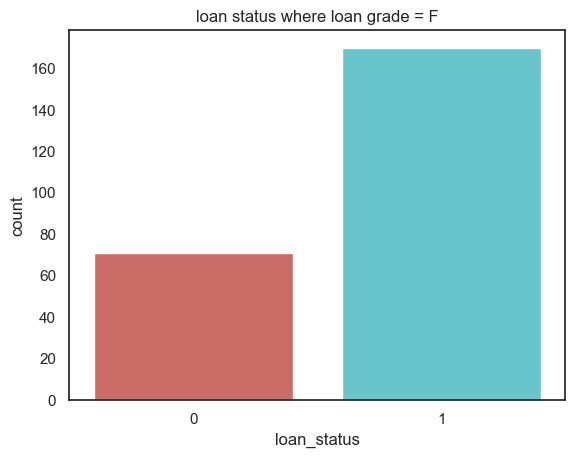

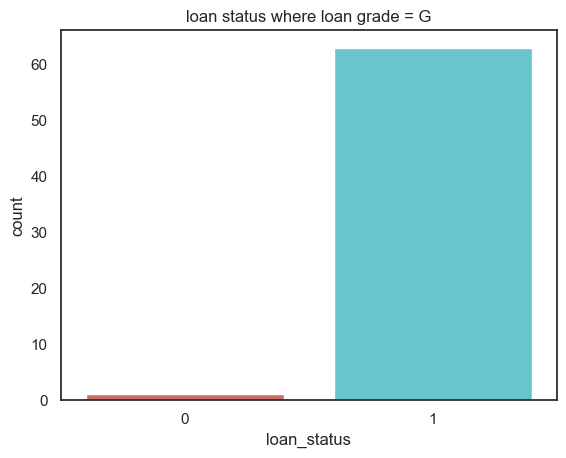

In [29]:
for char in ['D','E','F','G']:
    sns.countplot(data=df_credit[df_credit.loan_grade == char], x="loan_status",hue="loan_status",palette="hls", legend=False)
    plt.title(f"loan status where loan grade = {char}")
    plt.show()

##### home ownership

In [30]:
df_credit.person_home_ownership.unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [31]:
for type in ['RENT', 'OWN', 'MORTGAGE', 'OTHER']: 
    print (f"default rate for instances with home ownership type = {type}  -----> {df_credit[df_credit.person_home_ownership== type].loan_status.mean() * 100}")

default rate for instances with home ownership type = RENT  -----> 31.609476126511172
default rate for instances with home ownership type = OWN  -----> 7.491221225126804
default rate for instances with home ownership type = MORTGAGE  -----> 12.61874485750617
default rate for instances with home ownership type = OTHER  -----> 31.132075471698112


##### It seems that only those clients with home ownership type labelled as rent and other are likely to default while those that either own their homes or have mortgages have low default rates

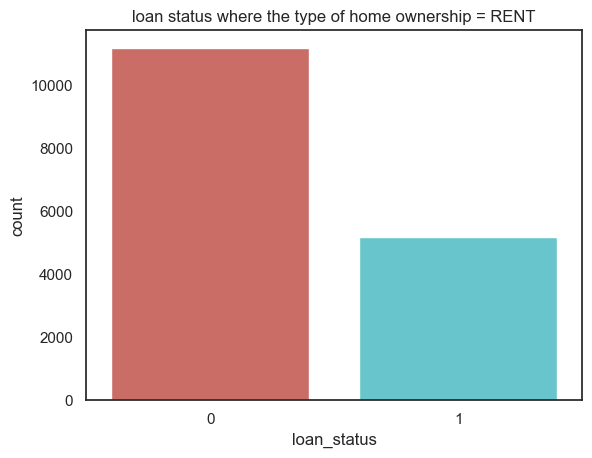

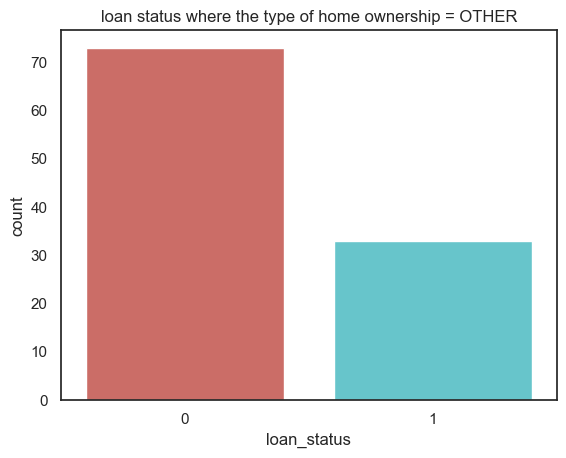

In [32]:
for type in ['RENT','OTHER']:
    sns.countplot(data=df_credit[df_credit.person_home_ownership == type], x="loan_status",hue="loan_status",palette="hls", legend=False)
    plt.title(f"loan status where the type of home ownership = {type}")
    plt.show()

##### Conclusion: why there are underlyfing factors that affect the probabily of a client to default:
##### 1. home ownership, loan grade (categorical) 
##### 2. loan interest rate, loan amount, loan percent income
##### Clients with loan grades DEFG are likely to default than clients with loan grade A, B, C. Also clients who neither own their own homes or have morgages tend to default more than those that do. The higher the loan interest rate, loan amount and loan percent income of clients, the more likely they are to default.

## Data Preprocessing

In [33]:
# dealing with na
df_cred = df.copy()
na_columns

['loan_int_rate', 'person_emp_length']

In [34]:
df_cred[df_cred.loan_int_rate.isna() == True].loan_status.mean()

np.float64(0.20710823909531503)

In [35]:
df_cred[df_cred.person_emp_length.isna() == True].loan_status.mean()

np.float64(0.31679819616685456)

In [36]:
na_columns

['loan_int_rate', 'person_emp_length']

In [37]:
df_cred.loan_int_rate= df_cred['loan_int_rate'].fillna(df_cred.loan_int_rate.mean())
df_cred.person_emp_length= df_cred['person_emp_length'].fillna(df_cred.person_emp_length.mean())

In [38]:
# feature engineering
df_cred['credit_start_year'] = df_cred.person_age - df_cred.cb_person_cred_hist_length
df_cred.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,credit_start_year
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,19
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,19
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,22
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,21
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,20


In [39]:
df_cred.drop(columns=['cb_person_cred_hist_length','person_age'],inplace=True)


In [40]:
num_cols_2 = ['person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income','credit_start_year']
#overwrite num_cols

In [41]:
ordinal = ['loan_grade']
one_hot = ['person_home_ownership','loan_intent','cb_person_default_on_file']

In [42]:
#making pipelines
one_hot_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot_encode",OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encode",OrdinalEncoder(categories=[['A','B','C','D','E','F','G']])),
    ("scalar", StandardScaler())
])

num_pipeline = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy="mean")),
    ("scalar", StandardScaler())
])

preprocessor = ColumnTransformer(transformers = [
    ("num", num_pipeline,num_cols_2),
    ("ord", ordinal_pipeline, ordinal),
    ("one", one_hot_pipeline, one_hot)
], n_jobs=-1, remainder='passthrough')


In [43]:
# splitting dependent and independent variables
X = df_cred[['person_income', 'person_home_ownership', 'person_emp_length','loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate','loan_percent_income', 'cb_person_default_on_file',
       'credit_start_year']]
y = df_cred.loan_status
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.7,random_state=2)
print("X_train.shape ---->", X_train.shape)
print("y_train.shape ---->", y_train.shape)
print("X_test.shape ---->", X_test.shape)
print("y_test.shape ---->", y_test.shape)


X_train.shape ----> (22691, 10)
y_train.shape ----> (22691,)
X_test.shape ----> (9725, 10)
y_test.shape ----> (9725,)


In [44]:
#getting indices of categorical columns for smotenc
cat_indices =[X_train.columns.get_loc(col) for col in cat_cols]
cat_indices

[1, 3, 4, 8]

In [45]:
#using smotenc for dealing with imbalanced data
# from imblearn.over_sampling import SMOTENC
# sm = SMOTENC(categorical_features=cat_indices, random_state=2) # SMOTENC used for mixed datasets
# X_train, y_train =sm.fit_resample(X_train,y_train)

In [46]:
# applying preprocessing
preprocessor.set_output(transform="pandas")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

## Model Selection and Training. Goal -----> minimizing FNs, maximizing Recall

### training xgbclassifier model

In [47]:
ratio = float(sum(y_train == 0)) / sum(y_train ==1)

In [48]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight = ratio, #for imbalanced data
    use_label_encoder=False
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

gridsearch_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2      # shows progress 
    )

gridsearch_xgb.fit(X_train_preprocessed, y_train)
print(gridsearch_xgb.best_score_)


Fitting 5 folds for each of 729 candidates, totalling 3645 fits


c:\Users\deoff\anaconda3\envs\datascience_main\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:29:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.8207600330564713


In [49]:
# metrics ----> classification_report, confusion_matrix
print(classification_report(y_test,(gridsearch_xgb.best_estimator_.predict_proba(X_test_preprocessed)[:,1] > 0.31).astype(int)))
print(confusion_matrix(y_test,(gridsearch_xgb.best_estimator_.predict_proba(X_test_preprocessed)[:,1] > 0.31).astype(int)))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7511
           1       0.80      0.80      0.80      2214

    accuracy                           0.91      9725
   macro avg       0.87      0.87      0.87      9725
weighted avg       0.91      0.91      0.91      9725

[[7056  455]
 [ 434 1780]]


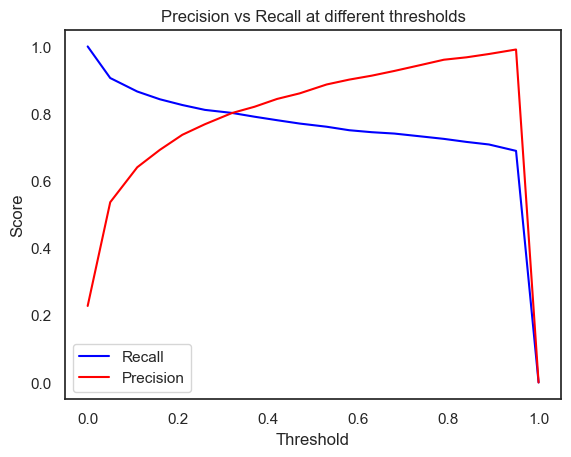

In [50]:
recalls = []
precisions = []
thresholds = []
for t in np.round(np.linspace(0,1,20),2):
    thresholds.append(t)    
    y_prob = (gridsearch_xgb.best_estimator_.predict_proba(X_test_preprocessed)[:,1] > t).astype(int)
    recalls.append(recall_score(y_test,y_prob,zero_division=0))
    precisions.append(precision_score(y_test,y_prob,zero_division=0))

#plotting precision and recall at different thresholds
plt.plot(thresholds,recalls,color='blue',label = 'Recall')
plt.plot(thresholds,precisions,color='red', label = 'Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at different thresholds')
plt.legend()
plt.show()
    

In [ ]:
print("roc_auc_score ----->", roc_auc_score(y_test,(gridsearch_xgb.best_estimator_.predict_proba(X_test_preprocessed)[:,1] > 0.31).astype(int)))

roc_auc_score -----> 0.8699421817588343


#### Conclusion: Using xgbclassifier to train a balanced model with an f1-score of 0.8 and recall and precision of 0.8 each. For all the clients that the model predicts to be defaulters, the model will be correct 80 percent of the time and for all the clients predicted to be non-defaulters the model will also be corect 80 percent of the time. 

#### XGBClassifier metrics

In [1]:
xgb_metrics = pd.DataFrame(data={
    "model": "XGBClassifier",
    "recall_score": 0.80,
    "precision_score": 0.80,
    "f1_score": 0.80,
    "roc_auc_score": 0.87
},index=[0])
xgb_metrics

NameError: name 'pd' is not defined